In [1]:
#!pip install keras

In [2]:
#!pip install tensorflow

In [47]:
#!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 74.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 76.9 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
import keras
import matplotlib.pyplot as plt

I0000 00:00:1781051086.713847   52195 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781051086.751192   52195 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781051087.963436   52195 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [29]:
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers
from sklearn import model_selection
from keras import regularizers
from datetime import datetime

In [5]:
df = pd.read_csv("data/heart_statlog_cleveland_hungary_final.csv")
df

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1


In [6]:
print("Shape original:", df.shape)
print("\nDistribuição do target:")
print(df['target'].value_counts())
print(f"\nProporção: {df['target'].value_counts(normalize=True).round(3).to_dict()}")

Shape original: (1190, 12)

Distribuição do target:
target
1    629
0    561
Name: count, dtype: int64

Proporção: {1: 0.529, 0: 0.471}


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [8]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [9]:
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

,Quantidade:,Percentual (%)
target,,
1,629,52.86
0,561,47.14


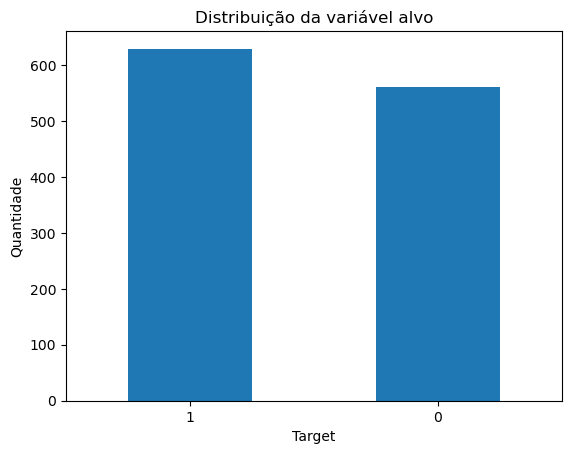

In [10]:
coluna_alvo = "target"

cont_alvos = df[coluna_alvo].value_counts()
porcent_alvo = df[coluna_alvo].value_counts(normalize = True) * 100

display(pd.DataFrame({
    "Quantidade:": cont_alvos,
    "Percentual (%)": porcent_alvo.round(2)
}))

cont_alvos.plot(kind="bar")
plt.title("Distribuição da variável alvo")
plt.xlabel("Target")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.show()

In [11]:
import seaborn as sns

sns.set_theme(style="whitegrid")

colunas_numericas = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]
colunas_categoricas = ["sex", "chest pain type", "fasting blood sugar",
                       "resting ecg", "exercise angina", "ST slope"]

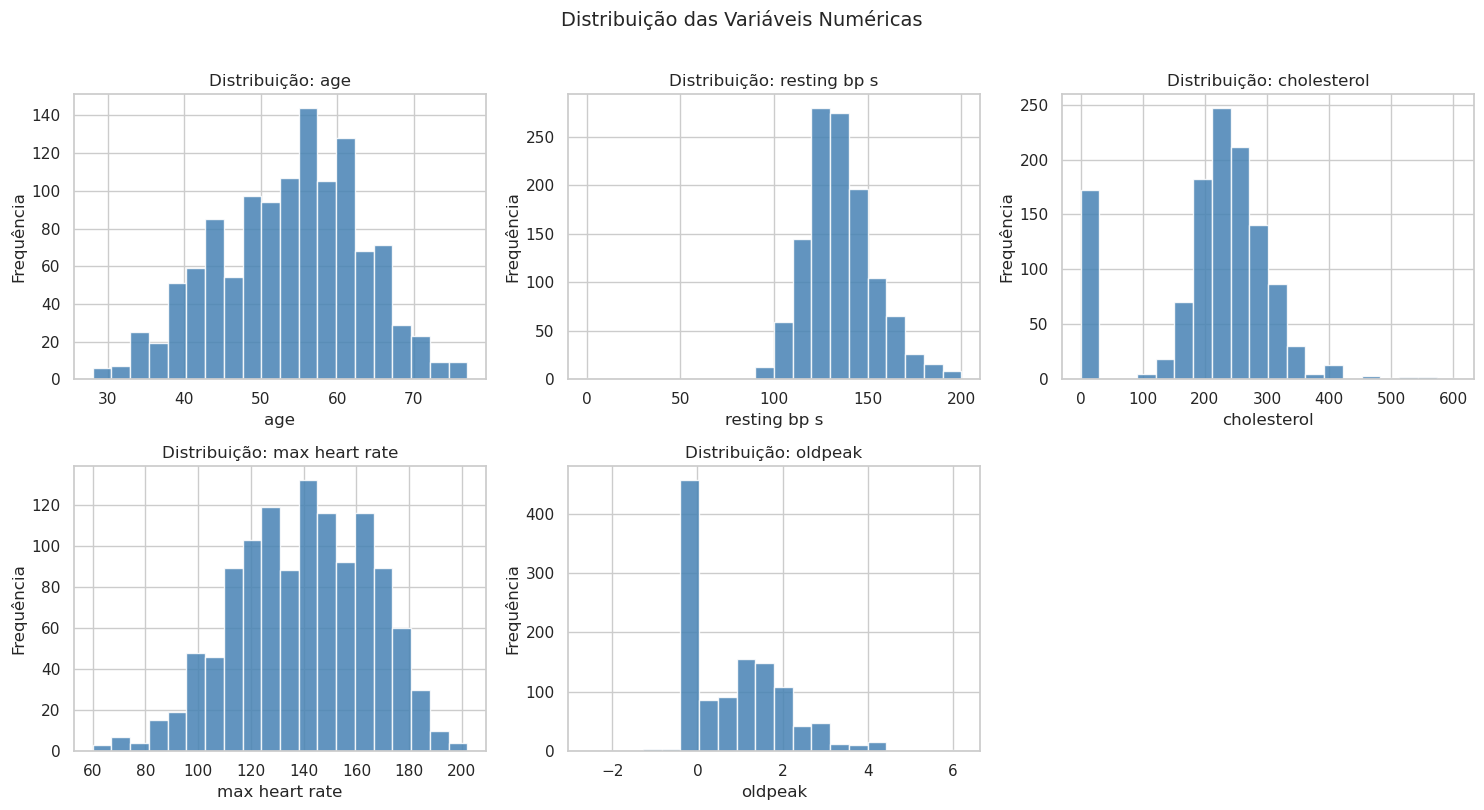

In [12]:
# ── 1. Distribuição das variáveis numéricas ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    axes[i].hist(df[col], bins=20, edgecolor="white", color="steelblue", alpha=0.85)
    axes[i].set_title(f"Distribuição: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequência")

axes[-1].set_visible(False)  # esconde o subplot vazio
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_52195/2928101948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_52195/2928101948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_52195/2928101948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
/tmp/ipykernel_52195/2928101948.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

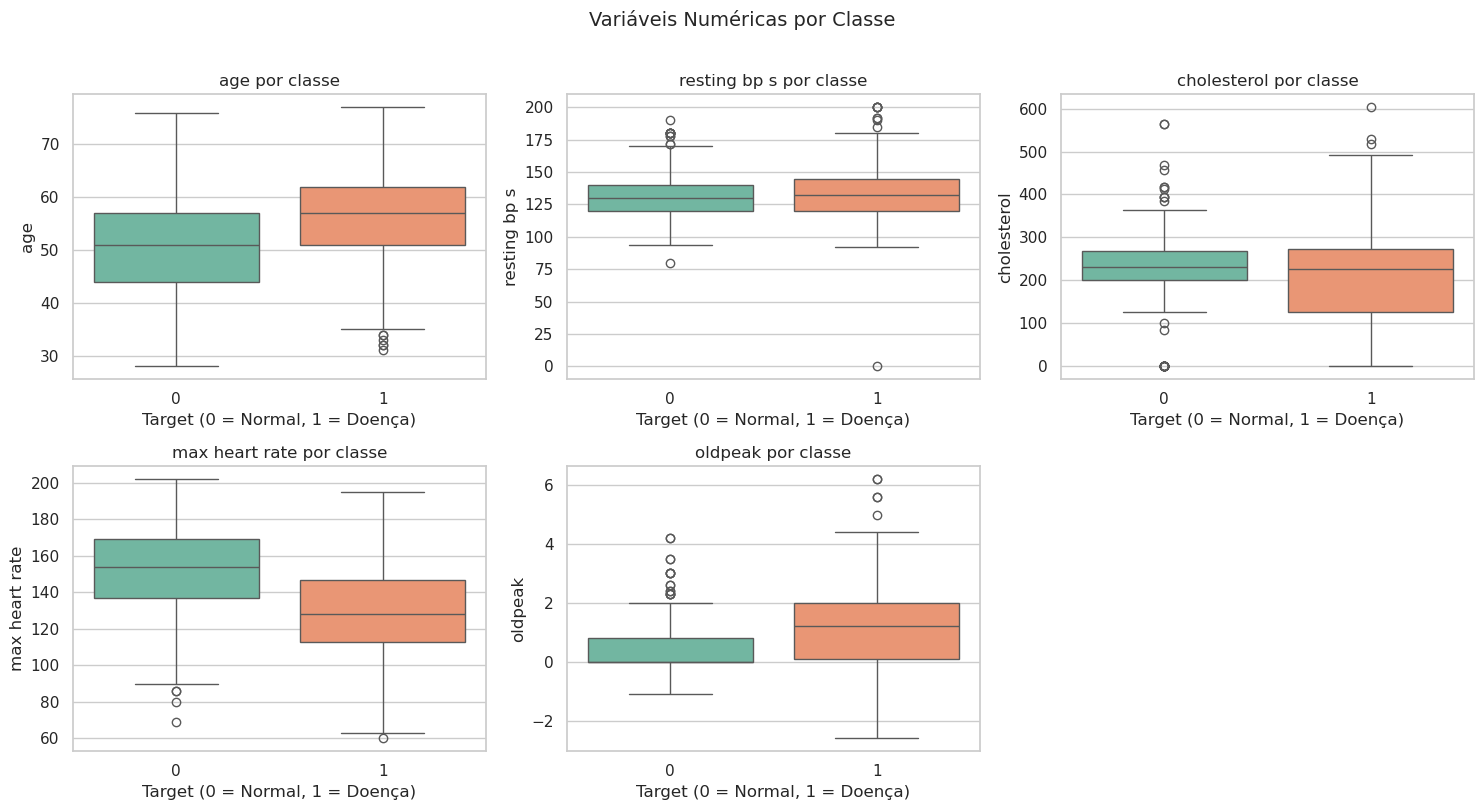

In [13]:
# ── 2. Boxplots por classe (target) ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(data=df, x="target", y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} por classe")
    axes[i].set_xlabel("Target (0 = Normal, 1 = Doença)")

axes[-1].set_visible(False)
plt.suptitle("Variáveis Numéricas por Classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

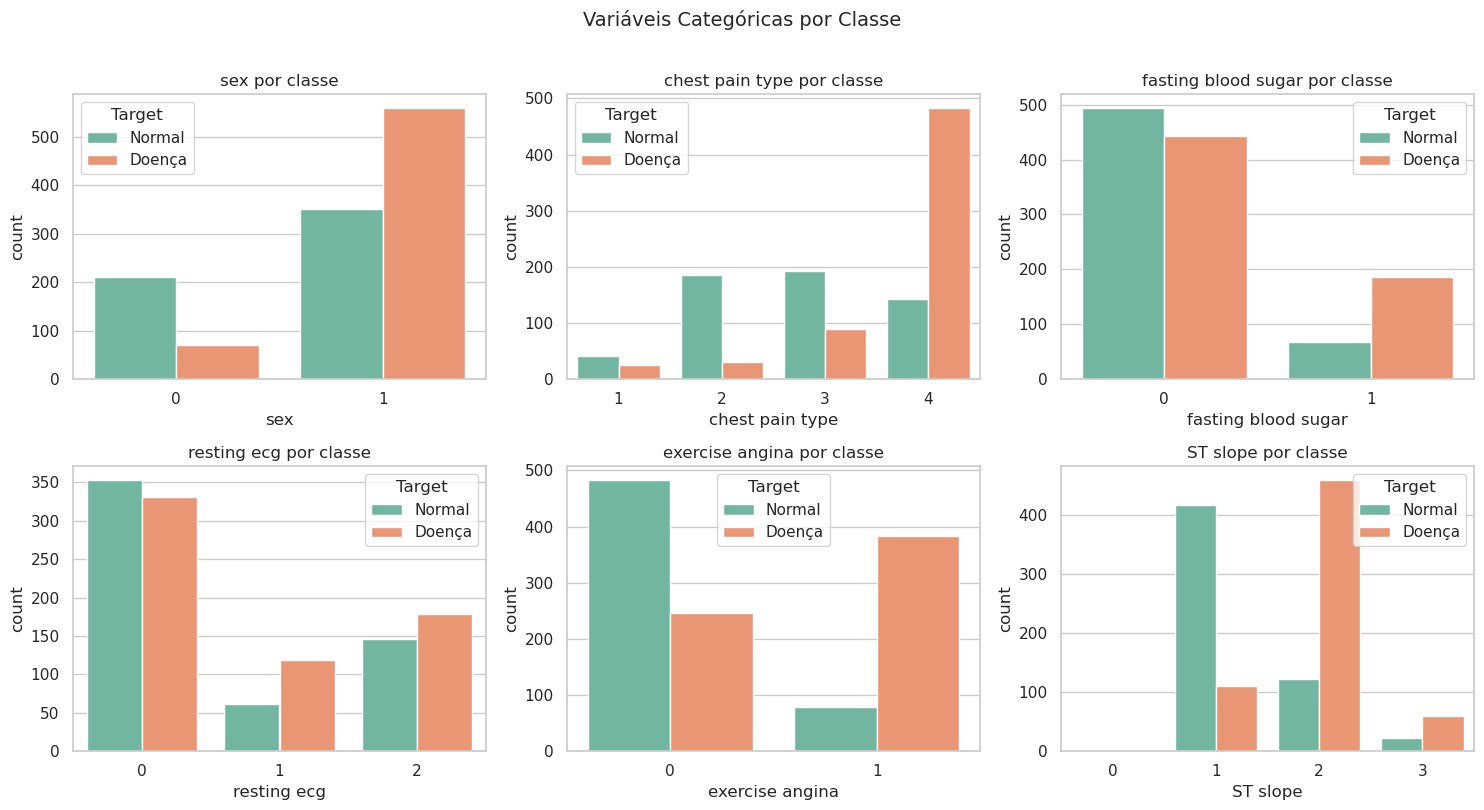

In [14]:
# ── 3. Countplots das variáveis categóricas por classe ────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    sns.countplot(data=df, x=col, hue="target", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} por classe")
    axes[i].set_xlabel(col)
    axes[i].legend(title="Target", labels=["Normal", "Doença"])

plt.suptitle("Variáveis Categóricas por Classe", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

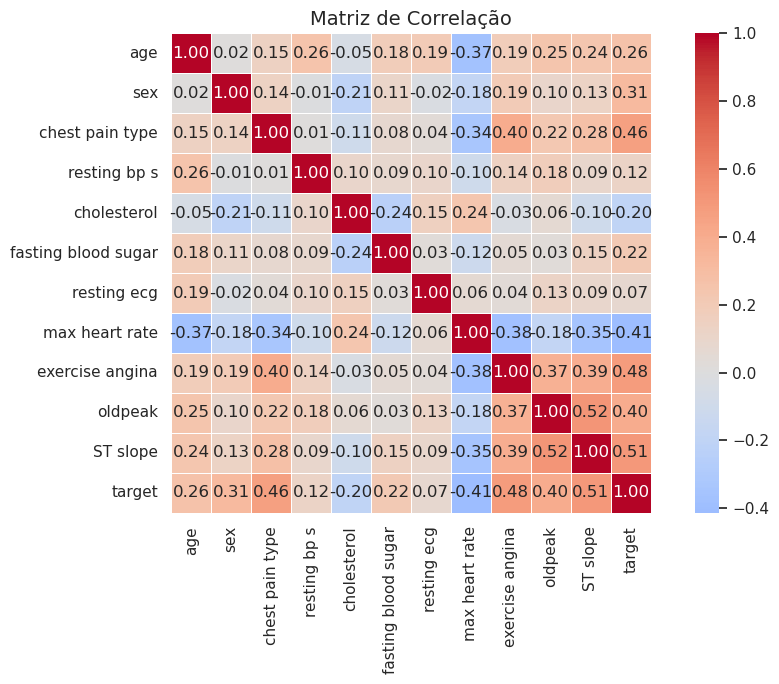

In [15]:
# ── 4. Matriz de correlação ───────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Matriz de Correlação", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
print(corr)

                          age       sex  chest pain type  resting bp s  \
age                  1.000000  0.015096         0.149055      0.257692   
sex                  0.015096  1.000000         0.138405     -0.006443   
chest pain type      0.149055  0.138405         1.000000      0.009466   
resting bp s         0.257692 -0.006443         0.009466      1.000000   
cholesterol         -0.046472 -0.208441        -0.109396      0.099037   
fasting blood sugar  0.178923  0.110961         0.076492      0.088235   
resting ecg          0.194595 -0.022225         0.035705      0.095860   
max heart rate      -0.368676 -0.181837        -0.337491     -0.101357   
exercise angina      0.188095  0.194380         0.403428      0.142435   
oldpeak              0.245093  0.096390         0.224106      0.176111   
ST slope             0.237749  0.127913         0.276949      0.089384   
target               0.262029  0.311267         0.460127      0.121415   

                     cholesterol  fas

In [17]:
# ── 5. Outliers via IQR (resumo tabular) ─────────────────────────
def contar_outliers_iqr(df, colunas):
    resultado = []
    for col in colunas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
        resultado.append({
            "Variável": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "N° Outliers": len(outliers),
            "% do total": f"{len(outliers)/len(df)*100:.1f}%"
        })
    return pd.DataFrame(resultado).set_index("Variável")

display(contar_outliers_iqr(df, colunas_numericas))

,Q1,Q3,IQR,N° Outliers,% do total
Variável,,,,,
age,47.0,60.00,13.00,0,0.0%
resting bp s,120.0,140.00,20.00,37,3.1%
cholesterol,188.0,269.75,81.75,193,16.2%
max heart rate,121.0,160.00,39.00,1,0.1%
oldpeak,0.0,1.60,1.60,11,0.9%


In [18]:
print((df["cholesterol"] == 0).sum())
df[df["cholesterol"] == 0]["cholesterol"].describe()

172


count    172.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: cholesterol, dtype: float64

In [19]:
df[df["cholesterol"] == 0]

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
294,65,1,4,115,0,0,0,93,1,0.0,2,1
295,32,1,1,95,0,1,0,127,0,0.7,1,1
296,61,1,4,105,0,1,0,110,1,1.5,1,1
297,50,1,4,145,0,1,0,139,1,0.7,2,1
298,57,1,4,110,0,1,1,131,1,1.4,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
515,43,1,4,122,0,0,0,120,0,0.5,1,1
516,63,1,3,130,0,1,1,160,0,3.0,2,0
519,48,1,3,102,0,1,1,110,1,1.0,3,1
536,56,1,4,130,0,0,2,122,1,1.0,2,1


In [20]:
df[df["cholesterol"] == 0]["target"].value_counts()

target
1    152
0     20
Name: count, dtype: int64

In [21]:
colunas_numericas = ["age", "resting bp s", "cholesterol", "max heart rate", "oldpeak"]

for col in colunas_numericas:
    zeros = (df[col] == 0).sum()
    if zeros > 0:
        print(f"{col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)")

resting bp s: 1 zeros (0.1%)
cholesterol: 172 zeros (14.5%)
oldpeak: 455 zeros (38.2%)


In [22]:
# 1. resting bp s — 1 dado ausente
mediana_bp = df[df["resting bp s"] != 0]["resting bp s"].median()
df["resting bp s"] = df["resting bp s"].replace(0, mediana_bp)

# 2. cholesterol — 172 dados ausentes
mediana_col = df[df["cholesterol"] != 0]["cholesterol"].median()
df["cholesterol"] = df["cholesterol"].replace(0, mediana_col)

# 3. oldpeak — zeros são valores reais

# Verificação final
print(df[["resting bp s", "cholesterol", "oldpeak"]].describe())

       resting bp s  cholesterol      oldpeak
count   1190.000000  1190.000000  1190.000000
mean     132.263025   245.052941     0.922773
std       17.964330    52.983213     1.086337
min       80.000000    85.000000    -2.600000
25%      120.000000   214.000000     0.000000
50%      130.000000   240.000000     0.600000
75%      140.000000   269.750000     1.600000
max      200.000000   603.000000     6.200000


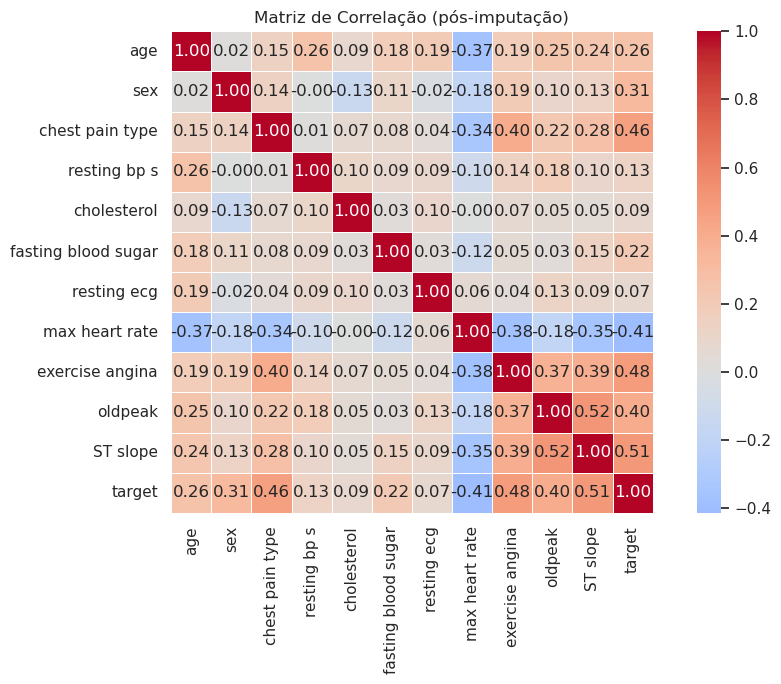

In [23]:
# Após a imputação, gere a matriz novamente
plt.figure(figsize=(10, 7))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Matriz de Correlação (pós-imputação)")
plt.tight_layout()
plt.show()

In [24]:
X = df.drop(columns=["target"])
y = df["target"]

# Treinamento da Rede Neural

# 1 - Separação dos dados em Treino-Teste-Validação

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")
print(f"Tamanho do conjunto de validação:  {X_val.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")
print(f"\nDistribuição na validação:\n{y_val.value_counts()}")


Tamanho do conjunto de treino: 833 amostras
Tamanho do conjunto de teste:  179 amostras
Tamanho do conjunto de validação:  178 amostras

Distribuição no treino:
target
1    440
0    393
Name: count, dtype: int64

Distribuição no teste:
target
1    95
0    84
Name: count, dtype: int64

Distribuição na validação:
target
1    94
0    84
Name: count, dtype: int64


# 1.1 - Visualização da distribuição

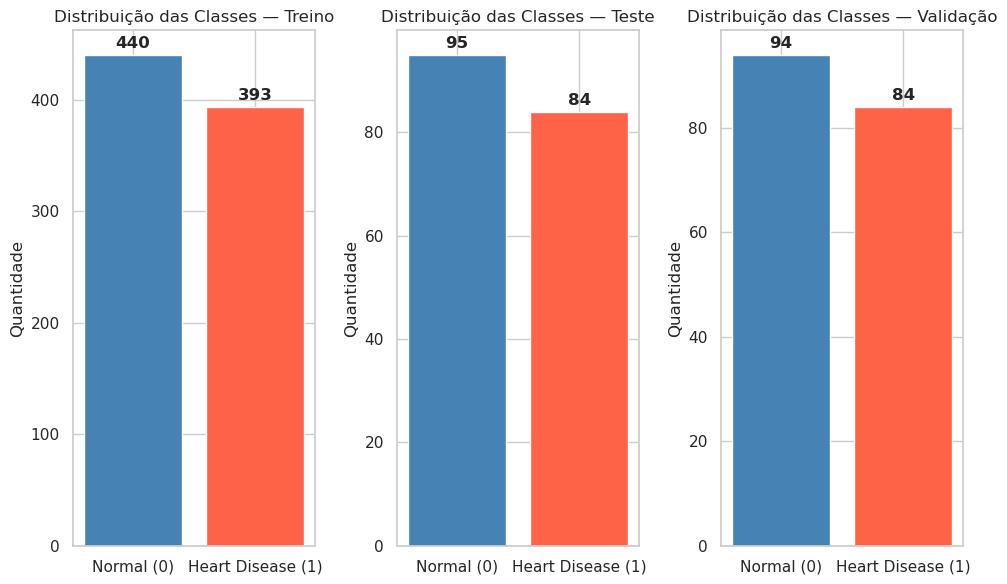

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
 
for ax, (data, title) in zip(axes, [
    (y_train, 'Treino'),
    (y_test,  'Teste'),
    (y_val, 'Validação')
]):
    counts = data.value_counts()
    bars = ax.bar(
        ['Normal (0)', 'Heart Disease (1)'],
        counts.values,
        color=['steelblue', 'tomato']
    )
    ax.bar_label(bars, padding=3, fontweight='bold')
    ax.set_title(f'Distribuição das Classes — {title}')
    ax.set_ylabel('Quantidade')
 
plt.tight_layout()
plt.show()

# 2 - Padronização

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train.copy())
X_test_std = scaler.transform(X_test.copy())
X_val_std = scaler.transform(X_val.copy())

# Verificação
print("Verificação pós-padronização (treino):")
print(pd.DataFrame(X_train_std, columns=X.columns)
      .describe().T[["mean", "std"]].round(4))

Verificação pós-padronização (treino):
                     mean     std
age                  -0.0  1.0006
sex                  -0.0  1.0006
chest pain type       0.0  1.0006
resting bp s          0.0  1.0006
cholesterol          -0.0  1.0006
fasting blood sugar  -0.0  1.0006
resting ecg           0.0  1.0006
max heart rate       -0.0  1.0006
exercise angina      -0.0  1.0006
oldpeak               0.0  1.0006
ST slope              0.0  1.0006


# 3 - Modelo

In [30]:
model = Sequential()

model.add(Input(shape=(11,)))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

None


# 4 - Treinamento

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_std, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_std, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.5863 - accuracy: 0.5462 - loss: 0.7317 - val_AUC: 0.7295 - val_accuracy: 0.6629 - val_loss: 0.6197
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.6816 - accuracy: 0.6327 - loss: 0.6614 - val_AUC: 0.8174 - val_accuracy: 0.7584 - val_loss: 0.5591
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.7658 - accuracy: 0.7059 - loss: 0.5906 - val_AUC: 0.8589 - val_accuracy: 0.8090 - val_loss: 0.5130
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8120 - accuracy: 0.7491 - loss: 0.5420 - val_AUC: 0.8803 - val_accuracy: 0.8146 - val_loss: 0.4785
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8281 - accuracy: 0.7431 - loss: 0.5180 - val_AUC: 0.8911 - val_accuracy: 0.8034 - val_loss: 0.4537
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.8518 - accuracy: 0.7779 - loss: 0.4886 - val_AUC: 0.8986 - val_accuracy: 0.8034 - val_loss: 0.4342
Epoch 7/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

# 5 - Curvas de aprendizado

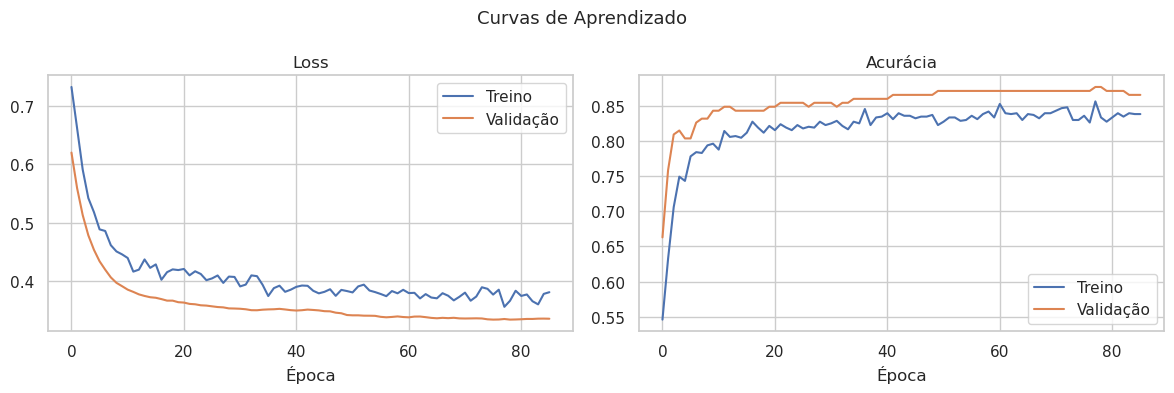

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Treino")
axes[0].plot(history.history["val_loss"], label="Validação")
axes[0].set_title("Loss")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Treino")
axes[1].plot(history.history["val_accuracy"], label="Validação")
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.suptitle("Curvas de Aprendizado", fontsize=13)
plt.tight_layout()
plt.show()

# 6 - Avaliação no conjunto de teste

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report
               precision    recall  f1-score   support

       Normal       0.82      0.87      0.84        84
Heart Disease       0.88      0.83      0.85        95

     accuracy                           0.85       179
    macro avg       0.85      0.85      0.85       179
 weighted avg       0.85      0.85      0.85       179

AUC-ROC: 0.9441


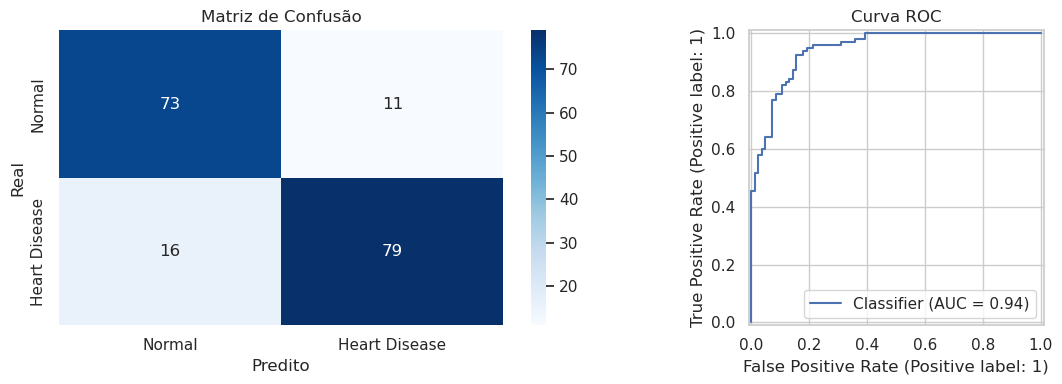

In [34]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

y_pred_prob = model.predict(X_test_std).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"])
axes[0].set_title("Matriz de Confusão")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predito")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1])
axes[1].set_title("Curva ROC")

plt.tight_layout()
plt.show()

In [39]:
print(f"{'Threshold':<12} {'Precision HD':<15} {'Recall HD':<12} {'F1 HD':<10} {'Acurácia'}")
print("-" * 60)

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:
    y_pred_t = (y_pred_prob >= threshold).astype(int)
    report = classification_report(y_test, y_pred_t, output_dict=True)
    hd = report["1"]
    acc = report["accuracy"]
    print(f"{threshold:<12.2f} {hd['precision']:<15.3f} {hd['recall']:<12.3f} {hd['f1-score']:<10.3f} {acc:.3f}")

Threshold    Precision HD    Recall HD    F1 HD      Acurácia
------------------------------------------------------------
0.50         0.878           0.832        0.854      0.849
0.45         0.869           0.905        0.887      0.877
0.40         0.863           0.926        0.893      0.883
0.35         0.820           0.958        0.883      0.866
0.30         0.805           0.958        0.875      0.855


Resultados com threshold = 0.4
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        84
Heart Disease       0.86      0.93      0.89        95

     accuracy                           0.88       179
    macro avg       0.89      0.88      0.88       179
 weighted avg       0.88      0.88      0.88       179

AUC-ROC: 0.9441


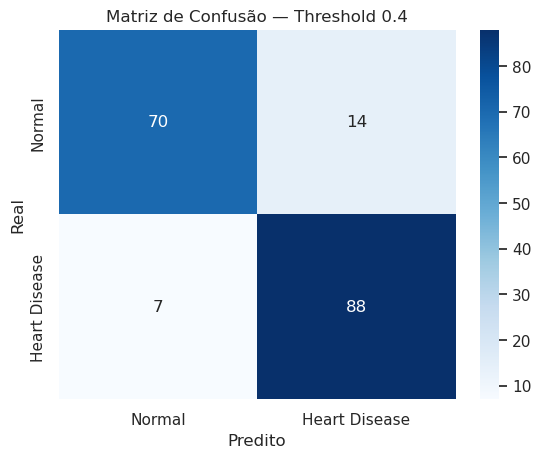

In [40]:
threshold_final = 0.40
y_pred_final = (y_pred_prob >= threshold_final).astype(int)

print("=" * 50)
print(f"Resultados com threshold = {threshold_final}")
print("=" * 50)
print(classification_report(y_test, y_pred_final,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Matriz de confusão atualizada
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Heart Disease"],
            yticklabels=["Normal", "Heart Disease"])
plt.title(f"Matriz de Confusão — Threshold {threshold_final}")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()

# Treinamento com Random Forest e XGBoost

In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_std, y_train)

y_pred_rf_prob = rf.predict_proba(X_test_std)[:, 1]
y_pred_rf = (y_pred_rf_prob >= 0.40).astype(int)

print(classification_report(y_test, y_pred_rf,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_rf_prob):.4f}")

               precision    recall  f1-score   support

       Normal       0.95      0.87      0.91        84
Heart Disease       0.89      0.96      0.92        95

     accuracy                           0.92       179
    macro avg       0.92      0.91      0.92       179
 weighted avg       0.92      0.92      0.92       179

AUC-ROC: 0.9496


In [48]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb.fit(X_train_std, y_train)

y_pred_xgb_prob = xgb.predict_proba(X_test_std)[:, 1]
y_pred_xgb = (y_pred_xgb_prob >= 0.40).astype(int)

print(classification_report(y_test, y_pred_xgb,
      target_names=["Normal", "Heart Disease"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_xgb_prob):.4f}")

               precision    recall  f1-score   support

       Normal       0.92      0.85      0.88        84
Heart Disease       0.87      0.94      0.90        95

     accuracy                           0.89       179
    macro avg       0.90      0.89      0.89       179
 weighted avg       0.90      0.89      0.89       179

AUC-ROC: 0.9585


In [49]:
#!pip install lazypredict

In [50]:
from lazypredict.Supervised import LazyClassifier

lazy = LazyClassifier(
    verbose=0,
    ignore_warnings=True,
    custom_metric=None
)

models, predictions = lazy.fit(X_train_std, X_test_std, y_train, y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
RandomForestClassifier         0.921788           0.921491  0.949624   
XGBClassifier                  0.910615           0.908897  0.958521   
ExtraTreesClassifier           0.888268           0.887845  0.960213   
SVC                            0.882682           0.879825  0.948496   
BaggingClassifier              0.877095           0.878697  0.934524   
ExtraTreeClassifier            0.871508           0.871366  0.871366   
NuSVC                          0.871508           0.869987  0.941855   
RidgeClassifierCV              0.849162           0.849624  0.925063   
LinearDiscriminantAnalysis     0.849162           0.849624  0.925313   
RidgeClassifier                0.849162           0.849624  0.925313   
QuadraticDiscriminantAnalysis  0.843575           0.844361  0.922932   
CalibratedClassifierCV         0.843575           0.842982  0.92

In [51]:
# Ver os 10 melhores por AUC
print(models.sort_values("ROC AUC", ascending=False).head(10))

                            Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                         
ExtraTreesClassifier        0.888268           0.887845  0.960213  0.888268   
XGBClassifier               0.910615           0.908897  0.958521  0.910446   
RandomForestClassifier      0.921788           0.921491  0.949624  0.921788   
SVC                         0.882682           0.879825  0.948496  0.882216   
NuSVC                       0.871508           0.869987  0.941855  0.871339   
BaggingClassifier           0.877095           0.878697  0.934524  0.877210   
RidgeClassifier             0.849162           0.849624  0.925313  0.849275   
LinearDiscriminantAnalysis  0.849162           0.849624  0.925313  0.849275   
RidgeClassifierCV           0.849162           0.849624  0.925063  0.849275   
LinearSVC                   0.837989           0.837719  0.924185  0.838040   

                            Precision    Recall  Ti